# Bug and Corrections notebook 

### Imports 

In [14]:
import pandas as pd
import logging
import sys
import numpy as np
from dataclasses import asdict
from pathlib import Path

# PROJECT PATH CONFIGURATION
# INSTRUCTION: Uncomment your specific path below and comment out others.
# This allows to switch between environments 

# user: matteograssini
#ProjectRoot = Path("/Users/matteograssini/Documents/GitHub/intraday-momentum")

# user: giuli 
#ProjectRoot = Path(r"C:\Users\giuli\Repositories\intraday-momentum")

# user: corwin 
#ProjectRoot = Path("/home/corwyn/Black_swan/Intraday_project/intraday-momentum/")

# user: patri
ProjectRoot = Path.cwd().parent
src_path = ProjectRoot / "src"

sys.path.insert(0, str(src_path))

print("ProjectRoot:", ProjectRoot)
print("src_path:", src_path, "exists:", src_path.exists())


src_path = ProjectRoot / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))
logging.basicConfig(
level=logging.INFO,
format="%(asctime)s | %(levelname)s | %(message)s",
force=True, # <-- allow printing in jupyter notebooks
)

from classes.metrics.metrics import MetricsCalculator
import classes.backtest.engine_new
from classes.backtest.default import BacktestDefaults

logger = logging.getLogger(__name__)

ProjectRoot: c:\Users\patri\Desktop\BlackSwan\Intraday_momentum\intraday-momentum-Sprint2_Grassini_Marechal_Engine_and_Backtest
src_path: c:\Users\patri\Desktop\BlackSwan\Intraday_momentum\intraday-momentum-Sprint2_Grassini_Marechal_Engine_and_Backtest\src exists: True


In [15]:
spy_path = ProjectRoot / "data/cleaned/SPY_1min_20231027_20251027.pkl"
div_path = ProjectRoot / "data/cleaned/SPY_div_2020-2025.csv"

df_spy = pd.read_pickle(spy_path)
df_spy.drop(columns=["close_deseasonalized"], inplace=True)
df_dividends = pd.read_csv(div_path)

# Print information about the dataframes
df_spy.info()
print("\n")
df_dividends.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 194105 entries, 2023-10-30 09:30:00 to 2025-10-27 15:59:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   volume  194105 non-null  float64
 1   open    194105 non-null  float64
 2   high    194105 non-null  float64
 3   low     194105 non-null  float64
 4   close   194105 non-null  float64
dtypes: float64(5)
memory usage: 8.9 MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   caldt     20 non-null     object 
 1   dividend  20 non-null     float64
 2   ticker    20 non-null     object 
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes


### Dividends

In [16]:
# Make a copy
df_dividends_prepared = df_dividends.copy()

# Rename columns to match what MetricsCalculator expects
df_dividends_prepared = df_dividends_prepared.rename(columns={
    "ex_dividend_date": "caldt",  # Metrics expects 'caldt'
    "cash_amount": "dividend"     # Metrics expects 'dividend'
})

# Convert 'caldt' to datetime
df_dividends_prepared["caldt"] = pd.to_datetime(df_dividends_prepared["caldt"])

# Keep only the necessary columns
df_dividends_prepared = df_dividends_prepared[["caldt", "dividend", "ticker"]]

# Verify
print(df_dividends_prepared.head())
print(df_dividends_prepared.columns)

       caldt  dividend ticker
0 2025-09-19   1.83111    SPY
1 2025-06-20   1.76112    SPY
2 2025-03-21   1.69553    SPY
3 2024-12-20   1.96555    SPY
4 2024-09-20   1.74553    SPY
Index(['caldt', 'dividend', 'ticker'], dtype='object')


### Metrics

In [17]:
from classes.metrics.metrics import MetricsCalculator

mc = MetricsCalculator()
mc = MetricsCalculator()
df_spy, df_spy_daily = mc.from_clean_df(df_spy, df_dividends)


2025-12-22 20:00:54,723 | INFO | Starting computation of market microstructure metrics...
2025-12-22 20:00:54,724 | INFO | Computing trading bounds...
2025-12-22 20:00:54,725 | INFO | Computing minute of day...
2025-12-22 20:00:54,777 | INFO | Computing opening prices...
2025-12-22 20:00:54,807 | INFO | Computing price movements...
2025-12-22 20:00:54,810 | INFO | Computing rolling volatility...
2025-12-22 20:00:55,051 | INFO | Computing previous close prices...
2025-12-22 20:00:55,085 | INFO | Computing reference prices...
2025-12-22 20:00:55,146 | INFO | Computing trading bounds...
2025-12-22 20:00:55,150 | INFO | Bounds computation completed.
2025-12-22 20:00:55,632 | INFO | Computing rolling volatility...
2025-12-22 20:00:55,682 | INFO | Cleaning dataframe before export...
2025-12-22 20:00:55,724 | INFO | df_all saved to data/processed/df_all_days.pkl
2025-12-22 20:00:55,726 | INFO | df_daily saved to data/processed/df_daily_groups.pkl


In [18]:
df_spy.head(395)

,Volume,Open,High,Low,Close,Minute_of_day,Upper_bnd,Lower_bnd,Vwap,Sigma,minute_of_day
Datetime,,,,,,,,,,,
2023-10-30 09:30:00,630285.0,413.560,413.9400,413.530,413.7700,0,NaN,NaN,413.746667,NaN,570
2023-10-30 09:31:00,322290.0,413.780,414.0100,413.750,413.8820,1,NaN,NaN,413.792004,NaN,571
2023-10-30 09:32:00,455364.0,413.910,414.2100,413.845,414.1400,2,NaN,NaN,413.880298,NaN,572
2023-10-30 09:33:00,269190.0,414.130,414.2400,414.050,414.2050,3,NaN,NaN,413.925994,NaN,573
2023-10-30 09:34:00,330914.0,414.205,414.3200,414.205,414.2700,4,NaN,NaN,413.981860,NaN,574
...,...,...,...,...,...,...,...,...,...,...,...
2023-10-31 09:30:00,558005.0,416.180,416.3700,415.760,415.7700,0,416.490665,415.269783,415.966667,NaN,570
2023-10-31 09:31:00,338641.0,415.770,415.8344,415.600,415.6399,1,416.612070,415.148553,415.862718,NaN,571
2023-10-31 09:32:00,241075.0,415.640,415.7900,415.590,415.7398,2,416.691937,415.068801,415.829638,NaN,572


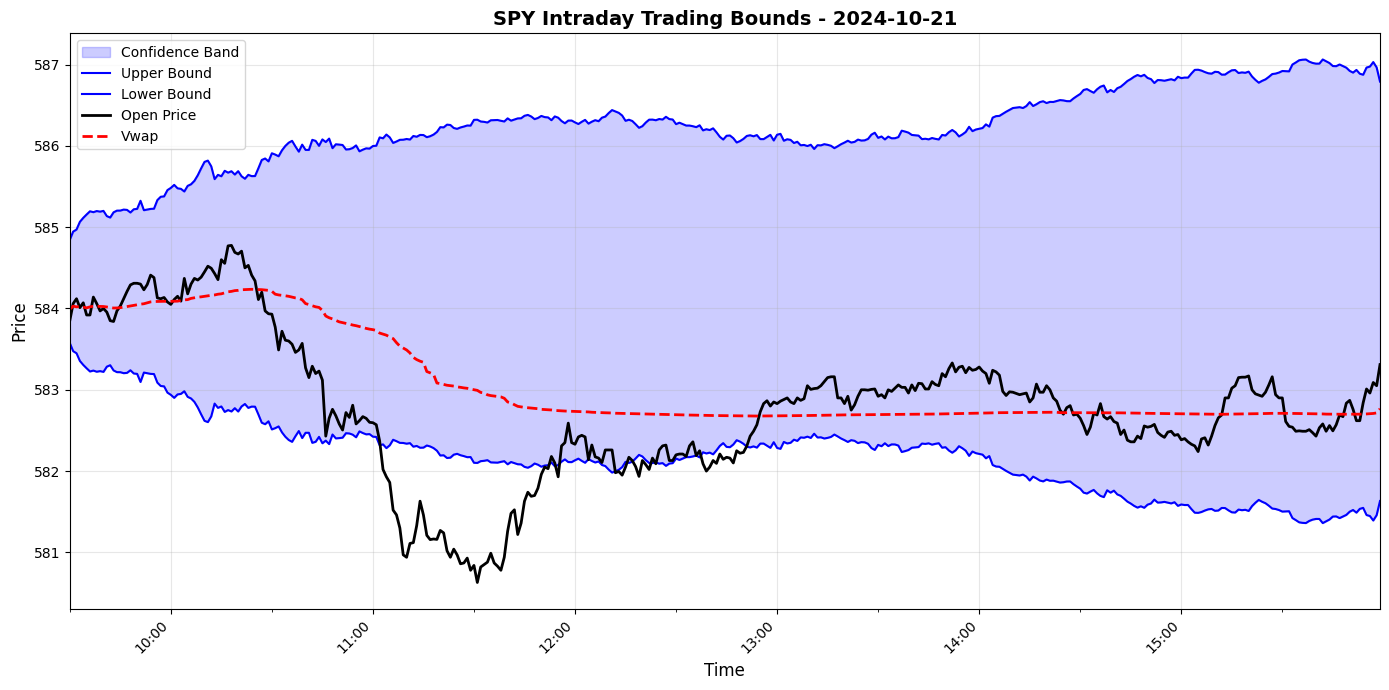

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import pandas as pd
import os


target_date = '2024-10-21'
target_date_dt = pd.to_datetime(target_date)

# Ensure index is datetime
df_spy.index = pd.to_datetime(df_spy.index)

# Filter by the index date
df_day = df_spy[df_spy.index.date == target_date_dt.date()].copy()

if df_day.empty:
    print(f"No intraday data for {target_date}")
    print(f"Available date range: {df_spy.index.min().date()} to {df_spy.index.max().date()}")
else:
    # Set a clean datetime index for matplotlib (use the index which is already datetime)
    if getattr(df_day.index, 'tz', None) is not None:
        try:
            df_day.index = df_day.index.tz_convert(None)
        except Exception:
            try:
                df_day.index = df_day.index.tz_localize(None)
            except Exception:
                pass

    # Create plot
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot the band with transparency
    ax.fill_between(df_day.index, df_day["Lower_bnd"], df_day["Upper_bnd"], 
                    alpha=0.2, color='blue', label='Confidence Band')

    # Plot Upper and Lower bounds
    ax.plot(df_day.index, df_day["Upper_bnd"], color='blue', linewidth=1.5, label='Upper Bound')
    ax.plot(df_day.index, df_day["Lower_bnd"], color='blue', linewidth=1.5, label='Lower Bound')

    # Plot Open price
    ax.plot(df_day.index, df_day["Open"], color='black', linewidth=2, label='Open Price')

    # Plot Vwap as dashed line if present
    if "Vwap" in df_day.columns:
        ax.plot(df_day.index, df_day["Vwap"], color='red', linewidth=2, label='Vwap', linestyle='--')

    # Create explicit major (hourly) and minor (30min) ticks using pandas date_range
    start = df_day.index[0].floor('h')
    end = df_day.index[-1].ceil('h')
    major_ticks = pd.date_range(start=start, end=end, freq='60min')
    minor_ticks = pd.date_range(start=start, end=end, freq='30min')

    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))

    # Tight x-limits and formatting
    ax.set_xlim([df_day.index[0], df_day.index[-1]])
    plt.xticks(rotation=45, ha='right')

    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(f'SPY Intraday Trading Bounds - {target_date}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

### Backtests

#### Band_only

In [20]:
from classes.backtest.engine_new import Momentum_Band
from backtesting import Backtest

bt = Backtest(
            data =df_spy,
            strategy = Momentum_Band,
            cash = 100_000,
            commission = (0.0035 + 0.001, 0) #First part is comission second is slippage 
            )

stats = bt.run()
print(stats)
bt.plot()

Start                     2023-10-30 09:30:00
End                       2025-10-27 15:59:00
Duration                    728 days 06:29:00
Exposure Time [%]                    11.58548
Equity Final [$]                  103572.5962
Equity Peak [$]                   106951.6355
Commissions [$]                         2.502
Return [%]                             3.5726
Buy & Hold Return [%]                65.59441
Return (Ann.) [%]                     1.78491
Volatility (Ann.) [%]                 3.56516
CAGR [%]                              1.22205
Sharpe Ratio                          0.50065
Sortino Ratio                         1.11015
Calmar Ratio                          0.35285
Alpha [%]                             4.57173
Beta                                 -0.01523
Max. Drawdown [%]                    -5.05853
Avg. Drawdown [%]                    -0.23678
Max. Drawdown Duration      206 days 05:09:00
Avg. Drawdown Duration        5 days 11:02:00
# Trades                          

C:\Users\patri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\backtesting\_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '2h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


GridPlot(id='p2413', ...)

#### Band + VWAP

In [21]:
from classes.backtest.engine_new import Momentum_Band_VWAP
from backtesting import Backtest

bt = Backtest(
            data =df_spy,
            strategy = Momentum_Band_VWAP,
            cash = 100_000,
            commission = (0.0035 + 0.001, 0) #First part is comission second is slippage 
            )

stats = bt.run()
print(stats)
bt.plot()

Start                     2023-10-30 09:30:00
End                       2025-10-27 15:59:00
Duration                    728 days 06:29:00
Exposure Time [%]                    10.20633
Equity Final [$]                  106758.5162
Equity Peak [$]                    109068.031
Commissions [$]                         2.502
Return [%]                            6.75852
Buy & Hold Return [%]                65.59441
Return (Ann.) [%]                     3.35105
Volatility (Ann.) [%]                 3.43411
CAGR [%]                              2.28878
Sharpe Ratio                          0.97581
Sortino Ratio                         2.45434
Calmar Ratio                          0.76255
Alpha [%]                             7.61281
Beta                                 -0.01302
Max. Drawdown [%]                    -4.39453
Avg. Drawdown [%]                    -0.19202
Max. Drawdown Duration      206 days 05:09:00
Avg. Drawdown Duration        4 days 14:18:00
# Trades                          

C:\Users\patri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\backtesting\_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '2h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


GridPlot(id='p2772', ...)

#### Band + VWAP + leverage

In [22]:
from classes.backtest.engine_new import Momentum_Band_VWAP_Lev
from backtesting import Backtest

bt = Backtest(
            data =df_spy,
            strategy = Momentum_Band_VWAP_Lev,
            cash = 100_000,
            commission = (0.0035 + 0.001 , 0),
            margin = 1/4
            )

stats = bt.run()
print(stats)
bt.plot()

Start                     2023-10-30 09:30:00
End                       2025-10-27 15:59:00
Duration                    728 days 06:29:00
Exposure Time [%]                    10.20633
Equity Final [$]                  120766.2119
Equity Peak [$]                   124340.5671
Commissions [$]                         2.502
Return [%]                           20.76621
Buy & Hold Return [%]                65.59441
Return (Ann.) [%]                     9.97665
Volatility (Ann.) [%]                 9.36569
CAGR [%]                              6.74688
Sharpe Ratio                          1.06523
Sortino Ratio                         3.01277
Calmar Ratio                          1.24142
Alpha [%]                            22.65694
Beta                                 -0.02882
Max. Drawdown [%]                    -8.03647
Avg. Drawdown [%]                    -0.46979
Max. Drawdown Duration      238 days 00:16:00
Avg. Drawdown Duration        4 days 20:11:00
# Trades                          

C:\Users\patri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\backtesting\_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '2h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


GridPlot(id='p3131', ...)

### Equity Curve Comparison: All Strategies vs. Buy-and-Hold

C:\Users\patri\AppData\Local\Temp\ipykernel_6476\1300942637.py:38: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run()


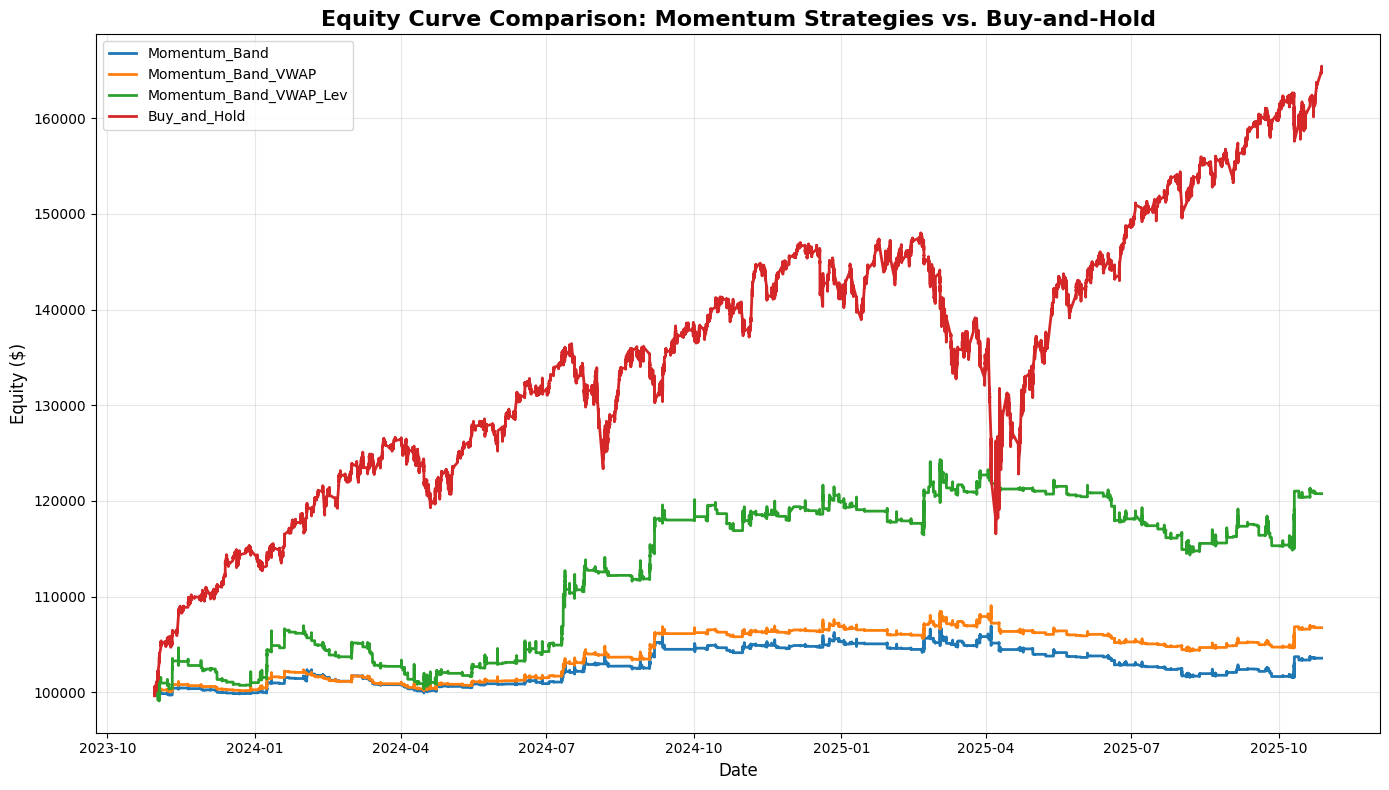

Final Equity Values:
Momentum_Band: $103572.60
Momentum_Band_VWAP: $106758.52
Momentum_Band_VWAP_Lev: $120766.21
Buy_and_Hold: $165376.07

Detailed Metrics for Buy-and-Hold Strategy:
Total Return: 65.38%
IRR (Annualized Return): 28.60%
Volatility (Ann.): 20.43%
Sharpe Ratio: 1.40
Hit Ratio (Win Rate): nan%
Max Drawdown (MDD): -21.25%


In [23]:
import matplotlib.pyplot as plt
from backtesting import Backtest, Strategy
from classes.backtest.engine_new import Momentum_Band, Momentum_Band_VWAP, Momentum_Band_VWAP_Lev

# Define a simple Buy-and-Hold strategy
class BuyAndHold(Strategy):
    def init(self):
        pass

    def next(self):
        if not self.position:
            self.buy()

# Common backtest parameters
cash = 100_000
commission = (0.0035 + 0.001, 0)

# Run all backtests
strategies = {
    'Momentum_Band': Momentum_Band,
    'Momentum_Band_VWAP': Momentum_Band_VWAP,
    'Momentum_Band_VWAP_Lev': Momentum_Band_VWAP_Lev,
    'Buy_and_Hold': BuyAndHold
}

equity_curves = {}
stats_dict = {}

for name, strategy in strategies.items():
    margin = 1/4 if name == 'Momentum_Band_VWAP_Lev' else 1
    bt = Backtest(
        data=df_spy,
        strategy=strategy,
        cash=cash,
        commission=commission,
        margin=margin
    )
    stats = bt.run()
    stats_dict[name] = stats
    equity_curves[name] = stats._equity_curve['Equity']

# Plot the equity curves
plt.figure(figsize=(14, 8))
for name, equity in equity_curves.items():
    plt.plot(equity.index, equity.values, label=name, linewidth=2)

plt.title('Equity Curve Comparison: Momentum Strategies vs. Buy-and-Hold', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Equity ($)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final equity for each strategy
print("Final Equity Values:")
for name, stats in stats_dict.items():
    print(f"{name}: ${stats['Equity Final [$]']:.2f}")

# Detailed metrics for Buy-and-Hold
print("\nDetailed Metrics for Buy-and-Hold Strategy:")
bh_stats = stats_dict['Buy_and_Hold']
print(f"Total Return: {bh_stats['Return [%]']:.2f}%")
print(f"IRR (Annualized Return): {bh_stats['Return (Ann.) [%]']:.2f}%")
print(f"Volatility (Ann.): {bh_stats['Volatility (Ann.) [%]']:.2f}%")
print(f"Sharpe Ratio: {bh_stats['Sharpe Ratio']:.2f}")
print(f"Hit Ratio (Win Rate): {bh_stats['Win Rate [%]']:.2f}%")
print(f"Max Drawdown (MDD): {bh_stats['Max. Drawdown [%]']:.2f}%")

### Robustness of the strategy

In [24]:
#INTRADAY MONTE CARLO PERMUTATION TEST 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from backtesting import Backtest

#Helpers
def _equity_series_from_stats(stats: pd.Series) -> pd.Series:
    eq = stats["_equity_curve"].copy()
    if isinstance(eq, pd.DataFrame) and "Equity" in eq.columns:
        equity = eq["Equity"].copy()
    else:
        equity = eq.squeeze()
    equity.index = pd.to_datetime(equity.index)
    return equity

def _daily_returns_from_equity(equity: pd.Series) -> pd.Series:
    daily = equity.resample("1D").last().dropna()
    return daily.pct_change().dropna()

def _sharpe_from_daily(daily_r: np.ndarray) -> float:
    mu = np.mean(daily_r)
    sd = np.std(daily_r, ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return (mu / sd) * np.sqrt(252)

def _total_return_from_daily(daily_r: np.ndarray) -> float:
    return float(np.prod(1.0 + daily_r) - 1.0)

def _max_drawdown_from_daily(daily_r: np.ndarray) -> float:
    eq = np.cumprod(1.0 + daily_r)
    peak = np.maximum.accumulate(eq)
    dd = (eq / peak) - 1.0
    return float(dd.min())  # negative

def _compute_metrics_from_stats(stats: pd.Series) -> dict:
    equity = _equity_series_from_stats(stats)
    dr = _daily_returns_from_equity(equity).values
    return {
        "sharpe": _sharpe_from_daily(dr),
        "total_return": _total_return_from_daily(dr),
        "max_drawdown": _max_drawdown_from_daily(dr),
    }

#Build a permuted intraday OHLCV DataFrame
def permute_intraday_within_day(df_base: pd.DataFrame, seed: int = 0) -> pd.DataFrame:
    """
    df_base: must have columns ['open','high','low','close','volume'] and datetime index.
    We shuffle within each day the sequence of 1-min close-to-close returns, then rebuild OHLC.
    High/low are reconstructed by preserving each bar's relative high/low ratios.
    Volume is kept in original time order (preserve intraday seasonality).
    """
    rng = np.random.default_rng(seed)
    df = df_base.copy()
    idx = pd.to_datetime(df.index)
    df["day"] = idx.date

    out_parts = []

    for day, g in df.groupby("day", sort=True):
        g = g.copy()

        o = g["open"].to_numpy(dtype=float)
        h = g["high"].to_numpy(dtype=float)
        l = g["low"].to_numpy(dtype=float)
        c = g["close"].to_numpy(dtype=float)
        v = g["volume"].to_numpy(dtype=float)

        n = len(g)
        if n < 3:
            out_parts.append(g.drop(columns=["day"]))
            continue

        # Returns to permute:
        # r0 maps open0 -> close0
        # r_t maps close_{t-1} -> close_t
        r = np.empty(n, dtype=float)
        r[0] = (c[0] / o[0]) - 1.0
        r[1:] = (c[1:] / c[:-1]) - 1.0

        perm = rng.permutation(n)     # shuffle all minute returns within the day
        r_perm = r[perm]

        # Preserve candle shape via ratios (avoid exploding highs/lows):
        top = np.maximum(o, c)
        bot = np.minimum(o, c)
        eps = 1e-12
        ratio_high = h / np.maximum(top, eps)
        ratio_low  = l / np.maximum(bot, eps)

        # Rebuild synthetic close path starting from original first open
        close_new = np.empty(n, dtype=float)
        open_new  = np.empty(n, dtype=float)

        open_new[0] = o[0]
        close_new[0] = open_new[0] * (1.0 + r_perm[0])

        for t in range(1, n):
            open_new[t] = close_new[t - 1]
            close_new[t] = close_new[t - 1] * (1.0 + r_perm[t])

        # Rebuild highs/lows using preserved ratios (attached to original bar "shape" order)
        top_new = np.maximum(open_new, close_new)
        bot_new = np.minimum(open_new, close_new)

        high_new = top_new * ratio_high
        low_new  = bot_new * ratio_low

        # Safety: enforce OHLC consistency
        high_new = np.maximum(high_new, top_new)
        low_new  = np.minimum(low_new, bot_new)

        g_out = pd.DataFrame(
            {
                "open": open_new,
                "high": high_new,
                "low": low_new,
                "close": close_new,
                "volume": v,
            },
            index=g.index,
        )

        out_parts.append(g_out)

    df_perm = pd.concat(out_parts).sort_index()
    return df_perm

#Observed performance (from your already-run stats) 
obs = _compute_metrics_from_stats(stats)
print("\nObserved strategy metrics (original data):")
print(obs)

#Prepare base data (raw OHLCV)
# If your current df_spy is the post-metrics one (capitalized), derive base from it:
if all(col in df_spy.columns for col in ["Open","High","Low","Close","Volume"]):
    df_base = df_spy[["Open","High","Low","Close","Volume"]].copy()
    df_base.columns = [c.lower() for c in df_base.columns]
else:
    # If df_spy is already raw lowercase OHLCV
    df_base = df_spy[["open","high","low","close","volume"]].copy()

#Monte Carlo loop: permute within-day + recompute metrics + backtest 
def intraday_within_day_permutation_backtest(
    df_base: pd.DataFrame,
    dividends_df: pd.DataFrame,
    n_sims: int = 300,
    seed: int = 123,
    cash: float = 100_000,
    commission: float = 0.0035,
    spread: float = 0.001,
    plot: bool = True
) -> pd.DataFrame:

    rng = np.random.default_rng(seed)
    sims = []

    # reuse one MetricsCalculator instance
    mc_local = MetricsCalculator()

    for i in range(n_sims):
        sim_seed = int(rng.integers(0, 2**31 - 1))
        df_perm_raw = permute_intraday_within_day(df_base, seed=sim_seed)

        # Recompute your features (VWAP, bounds, etc.) on permuted series
        df_perm_proc, _ = mc_local.from_clean_df(df_perm_raw, dividends_df, save=False)

        bt_perm = Backtest(
            data=df_perm_proc,
            strategy=Momentum_Band_VWAP_Lev,
            cash=cash,
            commission=commission,
            spread=spread,
        )

        st = bt_perm.run()
        m = _compute_metrics_from_stats(st)
        m["sim"] = i
        m["seed"] = sim_seed
        sims.append(m)

    res = pd.DataFrame(sims)
    return res

# Run permutations 
res = intraday_within_day_permutation_backtest(
    df_base=df_base,
    dividends_df=df_dividends_prepared,  # use your prepared dividends DF
    n_sims=200,
    seed=123,
    cash=100_000,
    commission=0.0035,
    spread=0.001,
    plot=False
)

print("\nNull distribution summary (within-day permuted intraday returns):")
print(res[["sharpe","total_return","max_drawdown"]].describe())

#p-values
# For Sharpe and total return: higher is better => p = P(null >= observed)
p_sharpe = (np.sum(res["sharpe"].values >= obs["sharpe"]) + 1) / (len(res) + 1)
p_ret    = (np.sum(res["total_return"].values >= obs["total_return"]) + 1) / (len(res) + 1)

# For max drawdown: less severe is better (closer to 0, i.e. larger) => p = P(null >= observed)
p_mdd    = (np.sum(res["max_drawdown"].values >= obs["max_drawdown"]) + 1) / (len(res) + 1)

print("\n========== Within-day Intraday Permutation Test ==========")
print(f"Observed Sharpe:       {obs['sharpe']:.6f} | p(null >= obs): {p_sharpe:.6f}")
print(f"Observed Total Return: {obs['total_return']:.6f} | p(null >= obs): {p_ret:.6f}")
print(f"Observed Max Drawdown: {obs['max_drawdown']:.6f} | p(null >= obs): {p_mdd:.6f}")
print("=========================================================\n")

#Plots
def _hist_plot(x, obs_val, title, xlabel, bins=50):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if x.size < 2 or np.unique(x).size < 2:
        print(f"Plot skipped for {title}: degenerate distribution.")
        return

    fig, ax = plt.subplots(figsize=(9, 4.5))

    # Null distribution (permutations)
    ax.hist(
        x,
        bins=bins,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.6,
        label="Permuted (null)"
    )

    # Observed value (real)
    ax.axvline(
        obs_val,
        linewidth=2.5,
        linestyle="-",
        label="Observed (real)"
    )

    # Optional: show a light marker at the observed value on the x-axis
    ax.scatter([obs_val], [0], zorder=5, s=40)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False)

    # Make the observed line always visible with a little padding
    xmin, xmax = ax.get_xlim()
    pad = 0.02 * (xmax - xmin)
    ax.set_xlim(min(xmin, obs_val) - pad, max(xmax, obs_val) + pad)

    plt.tight_layout()
    plt.show()



Observed strategy metrics (original data):
{'sharpe': np.float64(1.673624691193326), 'total_return': 0.6471315188968125, 'max_drawdown': -0.1892079349181789}


2025-12-22 20:01:30,899 | INFO | Starting computation of market microstructure metrics...
2025-12-22 20:01:30,901 | INFO | Computing trading bounds...
2025-12-22 20:01:30,902 | INFO | Computing minute of day...
2025-12-22 20:01:30,950 | INFO | Computing opening prices...
2025-12-22 20:01:30,981 | INFO | Computing price movements...
2025-12-22 20:01:30,984 | INFO | Computing rolling volatility...
2025-12-22 20:01:31,153 | INFO | Computing previous close prices...
2025-12-22 20:01:31,181 | INFO | Computing reference prices...
2025-12-22 20:01:31,235 | INFO | Computing trading bounds...
2025-12-22 20:01:31,239 | INFO | Bounds computation completed.
2025-12-22 20:01:31,660 | INFO | Computing rolling volatility...
2025-12-22 20:01:31,709 | INFO | Cleaning dataframe before export...
2025-12-22 20:01:34,912 | INFO | Starting computation of market microstructure metrics...
2025-12-22 20:01:34,914 | INFO | Computing trading bounds...
2025-12-22 20:01:34,915 | INFO | Computing minute of day...
2


Null distribution summary (within-day permuted intraday returns):
           sharpe  total_return  max_drawdown
count  200.000000    200.000000    200.000000
mean    -1.063648     -0.035460     -0.045376
std      0.831567      0.029430      0.019062
min     -2.243501     -0.092557     -0.092557
25%     -1.805838     -0.058426     -0.058798
50%     -1.359036     -0.040391     -0.044439
75%     -0.229514     -0.012904     -0.029534
max      0.572152      0.038042     -0.008523

========== Within-day Intraday Permutation Test ==========
Observed Sharpe:       1.673625 | p(null >= obs): 0.004975
Observed Total Return: 0.647132 | p(null >= obs): 0.004975
Observed Max Drawdown: -0.189208 | p(null >= obs): 1.000000

